In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import mean_absolute_error,r2_score

## 1. Загрузка и подготовка данных

Я загрузила датасет с помощью `pd.read_csv()`, преобразовала столбцы `Item_Outlet_Sales` и `Item_Weight` в числовой формат и удалила строки с пропусками в этих столбцах. Затем проверила размер таблицы, вывела первые три строки и рассчитала медианные продажи по типам магазинов.


In [3]:
df = pd.read_csv(r"big_mart_sales.csv")

df['Item_Outlet_Sales'] = pd.to_numeric(df['Item_Outlet_Sales'], errors='coerce')
df['Item_Weight'] = pd.to_numeric(df['Item_Weight'], errors='coerce')
df = df.dropna(subset=['Item_Outlet_Sales', 'Item_Weight'])

print(f"Размер таблицы: {df.shape[0]} товаров и {df.shape[1]} параметров")

outlet_impact = df.groupby("Outlet_Type")["Item_Outlet_Sales"].median()
print("\nМедианные продажи в зависимости от типа магазина:\n", outlet_impact)

df.head(3)

Размер таблицы: 7060 товаров и 12 параметров

Медианные продажи в зависимости от типа магазина:
 Outlet_Type
Grocery Store         250.3408
Supermarket Type1    1990.7420
Supermarket Type2    1655.1788
Name: Item_Outlet_Sales, dtype: float64


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700


Я подготовила данные и изучила структуру датасета, а также рассчитала медианные продажи для разных типов магазинов.


## 2. Анализ продаж по типам товаров

Я сгруппировала данные по `Item_Type`, рассчитала медианные продажи и отсортировала их по убыванию, чтобы вывести 10 типов товаров с наиболее высокими показателями.


In [10]:
item_type_impact = df.groupby("Item_Type")["Item_Outlet_Sales"].median().sort_values(ascending=False)
print("Топ-10 типов товаров по медианным продажам:\n", item_type_impact.head(10))

Топ-10 типов товаров по медианным продажам:
 Item_Type
Seafood                  2396.8800
Household                1970.7680
Starchy Foods            1968.1048
Snack Foods              1944.1360
Breads                   1845.5976
Canned                   1837.6080
Others                   1837.6080
Meat                     1823.6262
Fruits and Vegetables    1797.6600
Hard Drinks              1701.7848
Name: Item_Outlet_Sales, dtype: float64


Я определила 10 типов товаров с наиболее высокими медианными продажами с помощью группировки и сортировки данных.



## 3. Подготовка данных для модели

Я удалила столбцы с идентификаторами, преобразовала категориальные признаки с помощью `pd.get_dummies()` и разделила данные на признаки `X` и целевую переменную `y`. Затем выделила обучающую и тестовую выборки с помощью `train_test_split()` и масштабировала числовые признаки через `StandardScaler()`.


In [11]:
df_model = df.drop(columns=['Item_Identifier', 'Outlet_Identifier'])

df_model = pd.get_dummies(
    df_model,
    columns=[
        'Item_Fat_Content',
        'Item_Type',
        'Outlet_Size',
        'Outlet_Location_Type',
        'Outlet_Type'
    ],
    drop_first=True
)

X = df_model.drop('Item_Outlet_Sales', axis=1)
y = df_model['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

number_cols = [
    'Item_Weight',
    'Item_Visibility',
    'Item_MRP',
    'Outlet_Establishment_Year'
]

scaler = StandardScaler()
X_train[number_cols] = scaler.fit_transform(X_train[number_cols])
X_test[number_cols] = scaler.transform(X_test[number_cols])

X_train.head(3)


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,Item_Type_Breads,Item_Type_Breakfast,...,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2
7076,0.889736,-0.990646,1.400160,0.982539,False,True,False,False,False,False,...,False,True,False,False,False,False,True,False,True,False
8022,0.857435,1.974907,0.849919,-2.058218,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1117,-0.617669,-0.788943,1.958425,-0.537839,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False


Я преобразовала данные в подходящий формат, разделила их на обучающую и тестовую выборки и подготовила признаки для обучения модели.


## 4. Поиск оптимального количества соседей

Я проверила разные значения `k` для модели `KNeighborsRegressor()`. Для каждого варианта рассчитала MAE и построила график зависимости ошибки от количества соседей.



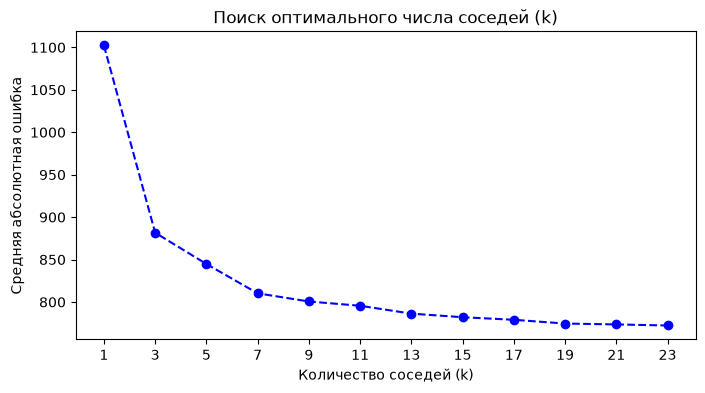

In [12]:
errors = []
k_values = range(1, 25, 2)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    errors.append(mean_absolute_error(y_test, y_pred))

plt.figure(figsize=(8, 4))
plt.plot(k_values, errors, marker="o", linestyle="dashed", color="blue")
plt.title("Поиск оптимального числа соседей (k)")
plt.xlabel("Количество соседей (k)")
plt.ylabel("Средняя абсолютная ошибка")
plt.xticks(k_values)
plt.show()

Я сравнила значения `k` по MAE и оценила по графику, как количество соседей влияет на ошибку прогнозирования.



## 5. Сравнение метрик расстояния

Я сравнила две модели KNN при `k = 5`: с евклидовым расстоянием (`p=2`) и манхэттенским расстоянием (`p=1`). Для оценки качества прогнозов рассчитала MAE и R².


In [13]:
best_k = 5

knn_euclidean = KNeighborsRegressor(n_neighbors=best_k, p=2)
knn_euclidean.fit(X_train, y_train)
y_pred_euc = knn_euclidean.predict(X_test)

knn_manhattan = KNeighborsRegressor(n_neighbors=best_k, p=1)
knn_manhattan.fit(X_train, y_train)
y_pred_man = knn_manhattan.predict(X_test)

print("=== Сравнение метрик расстояния ===")
print(f"Евклидово расстояние (p=2): MAE = {mean_absolute_error(y_test, y_pred_euc):.2f} | R2 = {r2_score(y_test, y_pred_euc):.2f}")
print(f"Манхэттенское расстояние (p=1): MAE = {mean_absolute_error(y_test, y_pred_man):.2f} | R2 = {r2_score(y_test, y_pred_man):.2f}")

=== Сравнение метрик расстояния ===
Евклидово расстояние (p=2): MAE = 844.82 | R2 = 0.44
Манхэттенское расстояние (p=1): MAE = 847.38 | R2 = 0.44


Я сравнила две метрики расстояния и оценила результаты моделей с помощью MAE и R².



## 6. Ядерная регрессия

Я проверила 30 значений параметра `gamma`, созданных с помощью `np.logspace()`. Для каждого значения рассчитала веса объектов с помощью `rbf_kernel()`, получила прогнозы и вычислила MAE и R². Затем выбрала параметр с наибольшим значением R².


In [14]:
gamma_values = np.logspace(-4, 0, 30)

best_gamma = 0
best_r2 = -float("inf")
best_mae = float("inf")

for g in gamma_values:
    weights = rbf_kernel(X_test, X_train, gamma=g)
    weights_normalized = weights / weights.sum(axis=1, keepdims=True)

    y_pred_nw = np.dot(weights_normalized, y_train.values)

    r2 = r2_score(y_test, y_pred_nw)
    mae = mean_absolute_error(y_test, y_pred_nw)

    if r2 > best_r2:
        best_r2 = r2
        best_mae = mae
        best_gamma = g

print("=== Итоги оптимизации ядерной регрессии ===")
print(f"Оптимальный gamma: {best_gamma:.4f}")
print(f"Лучшее R2: {best_r2:.2f}")
print(f"Лучшее MAE: {best_mae:.2f}")

=== Итоги оптимизации ядерной регрессии ===
Оптимальный gamma: 1.0000
Лучшее R2: 0.50
Лучшее MAE: 808.76


Я сравнила разные значения `gamma` и выбрала параметр, при котором ядерная регрессия показала наибольшее значение R².



## 7. Сравнение реальных и предсказанных продаж

Я построила диаграмму рассеяния с помощью `plt.scatter()`, чтобы сравнить реальные продажи с предсказанными. Диагональная пунктирная линия показывает идеальное совпадение значений.


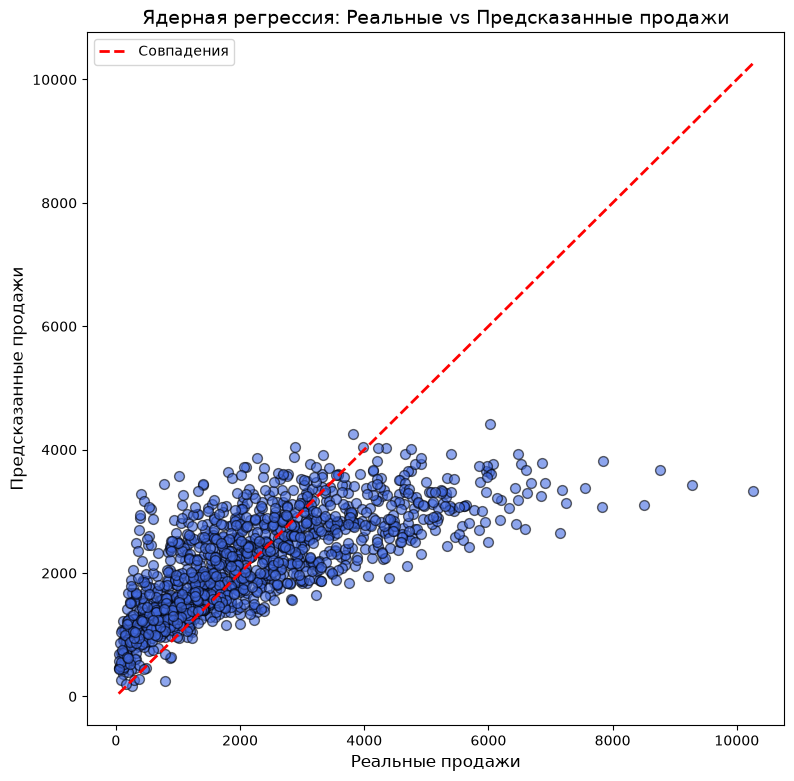

In [15]:
plt.figure(figsize=(9, 9))

plt.scatter(
    y_test,
    y_pred_nw,
    alpha=0.6,
    color="royalblue",
    edgecolor="k",
    s=50
)

max_val = max(y_test.max(), y_pred_nw.max())
min_val = min(y_test.min(), y_pred_nw.min())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    lw=2,
    label="Совпадения"
)

plt.title(
    "Ядерная регрессия: Реальные vs Предсказанные продажи",
    fontsize=14
)
plt.xlabel("Реальные продажи", fontsize=12)
plt.ylabel("Предсказанные продажи", fontsize=12)
plt.legend()
plt.show()

По расположению точек относительно диагональной линии я оценила, насколько предсказания ядерной регрессии близки к реальным продажам.



## Общий вывод

В ходе работы я загрузила и подготовила датасет Big Mart, проанализировала продажи по типам магазинов и товаров. Затем я построила модель KNN, сравнила разные значения количества соседей и метрики расстояния. Также я реализовала ядерную регрессию с RBF-ядром и подобрала параметр `gamma`. Для оценки качества прогнозов я использовала MAE и R², а результаты ядерной регрессии дополнительно рассмотрела на графике.

